## CHAMP Test Run

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

file_path = 'D:\\GitHub\\DataIO\\'
sys.path.append(os.path.dirname(file_path))

from data_io import toleos_den

Latest SHA: 0982aaafa7d77cdbb6472d9454fb27669c15883d


In [3]:
from contigo.contigo_utils import orekit_utils
import jpype

print(jpype.isJVMStarted())
orekit_utils.start_orekit()
print(jpype.isJVMStarted())

False
Starting Orekit JVM
Loading Orekit data from D:\GitHub\contigo_edr\contigo\data\orekit_data_0982aaaf.zip
True


INFO:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:NumExpr defaulting to 16 threads.


ImportError: DLL load failed while importing _netCDF4: The specified procedure could not be found.

In [ ]:
#import orekit_jpype as orekit


#orekit.initVM(jvmpath="C://Program Files//Eclipse Adoptium//jdk-17.0.18.8-hotspot//bin//server//jvm.dll",
#              additional_classpaths=[r"D:\GitHub\contigo_edr\java_src\target\orekit_utils-1.0.0.jar"])

#from orekit_jpype.pyhelpers import setup_orekit_data, download_orekit_data_curdir
#download_orekit_data_curdir()
#setup_orekit_data(from_pip_library=False)

In [ ]:
import pandas as pd
import numpy as np
import glob


import matplotlib.pyplot as plt

from contigo.contigo_utils.utils import df_sp3

from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

# Ephemeris
from contigo.ephemeris.orekit_ephem import OrekitEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

# Forces and acceleration
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_orekit import SRPOrekitCB

Starting Orekit JVM
Loading Orekit data to D:\GitHub\contigo_edr\contigo\data\orekit_data.zip


In [ ]:
fn = [r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050821_100000_20050822_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050821_220000_20050822_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050822_100000_20050823_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050815_100000_20050816_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050815_220000_20050816_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050816_100000_20050817_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050816_220000_20050817_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050817_100000_20050818_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050817_220000_20050818_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050818_100000_20050819_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050818_220000_20050819_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050819_100000_20050820_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050819_220000_20050820_120000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050820_100000_20050821_000000_v01.sp3.gz",
r"D:\data\SatDensities\CHAMP\GFZOP_RSO_L06_G_20050820_220000_20050821_120000_v01.sp3.gz",]

In [ ]:
ch_orb = pd.concat([df_sp3(f) for f in fn])
print(ch_orb.shape)
ch_orb = ch_orb.drop_duplicates(subset='time', keep='first', inplace=False, ignore_index=True)
ch_orb = ch_orb.sort_values(by='time').reset_index()
print(ch_orb.shape)

(25215, 8)
(21841, 9)


In [ ]:
ch_orb['v'] = np.linalg.norm(ch_orb[['vx','vy','vz']].to_numpy(),axis=1)
ch_orb['r'] = np.linalg.norm(ch_orb[['x','y','z']].to_numpy(),axis=1)
ch_orb['DateTime'] = ch_orb['time']
ch_orb['cd'] = 3.5 
ch_orb['drag_area'] = 0.80
ch_orb['cr'] = 1.28
ch_orb['srp_area'] = 2.25
ch_orb['mass'] = 500
ch_orb['id'] = 'CHAMP'

In [ ]:
ch_tol, ch_meta, _ = toleos_den.load_toleos(sat='CH',sdate='2005-08-15',edate='2005-08-23') 

ch_tol['rho_x_km'] = ch_tol['rho_x']*(1000.**3)
ch_tol['rho_mean_km'] = ch_tol['rho_mean']*(1000.**3) 
ch_tol['DateTime'] = ch_tol['DateTime'].to_numpy().astype('datetime64[ns]')

In [ ]:
cols = ['DateTime','rho_x_km']
ch_comb = pd.merge_asof(ch_orb, ch_tol[cols], left_on='DateTime', right_on='DateTime',
                         tolerance=pd.Timedelta('15s')).dropna()

<Axes: xlabel='time'>

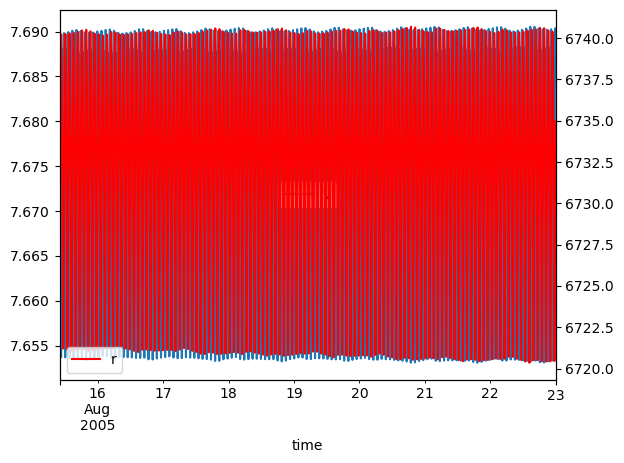

In [ ]:
ax = ch_orb.plot(x='time',y='v')
axt = ax.twinx()
ch_orb.plot(x='time',y='r',ax=axt, color='r')

In [ ]:
hdf_sc = Constellation(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')

hdf_sc

Constellation(n_spacecraft=1, ids=['CHAMP'])

In [ ]:
# setup the ephemeris provider we want
# and the solar system environement 
# which defines the tolerance for ephemeris cacheing and the bodies we want
# in our solar system
ephem = OrekitEphem( )

env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem, 
                            ephem_time=hdf_sc.sspice_et, 
                            gps_time=hdf_sc.sspice_gps,
                            utc_time=hdf_sc.sc_utc)

# this is a big lmax but this is what 
# we use in the orekit derivation and
# is what we need here to for a comparison
ep = EarthPotential(lmax=40) 
tba_env = ThirdBodyEnv( )
srp = SRPOrekitCB( )

# create the EDRDensity object and calculate
# EDR and the denom
edr = EDRDensity(constellation=hdf_sc,
                 solarsys_env=env, 
                 force_models=[tba_env,srp],
                 potential_model=ep)

acc_con = edr.compute_edr()
den_con = edr.compute_denom()
efd_con = edr.compute_den()

INFO:Loading potential file D:\GitHub\contigo_edr\contigo\data\EIGEN-2.gfc
INFO:Loading Potential coeffecients from current state which used EIGEN-2.gfc.


ThirdBodyAcceleration
SRPOrekitCannonball
ThirdBodyAcceleration
SRPOrekitCannonball
CHAMP


<Axes: xlabel='DateTime'>

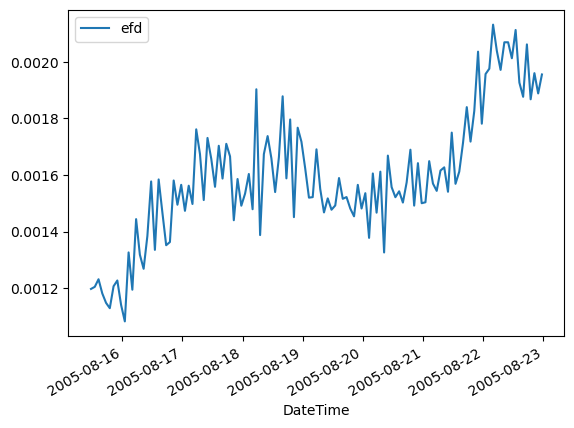

In [ ]:
efd_con['CHAMP'].plot(x='DateTime',y='efd')

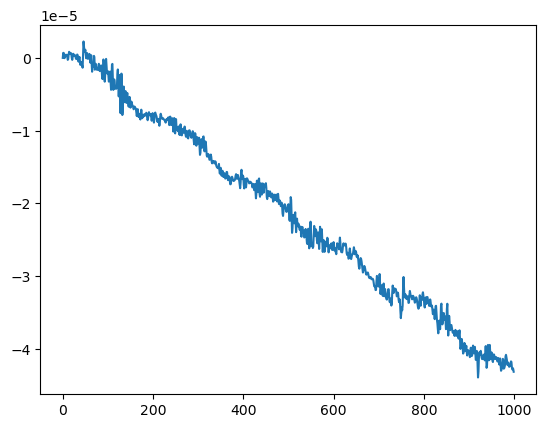

In [ ]:
plt.plot(acc_con['CHAMP']['edr'][0:1000])

<Axes: xlabel='DateTime'>

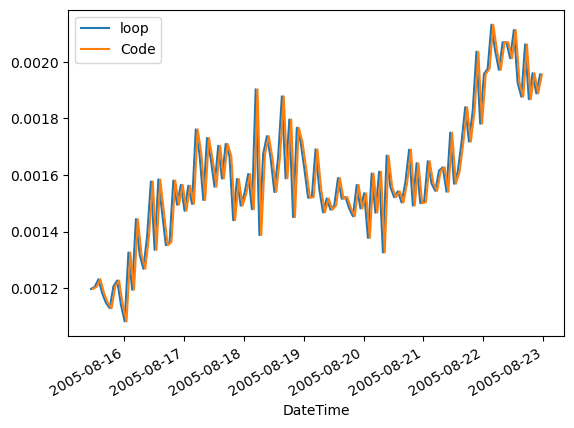

In [ ]:
sat_der='CHAMP'
step = pd.Timedelta(minutes=90)
s = edr.constellation[sat_der].sc_utc[0]
e = s+step

delta_edr = []
delta_den = []
d_dt = []

edr_sw = pd.Series(acc_con[sat_der]['edr']).rolling(10, min_periods=1, center=True).mean().to_numpy()

while e < edr.constellation.sc_utc.max():
    gd_ind = np.where((edr.constellation[sat_der].sc_utc >= s) & (edr.constellation[sat_der].sc_utc < e))

    id_min = gd_ind[0].min() 
    id_max = gd_ind[0].max()

    delta_edr.append(edr_sw[id_max]-edr_sw[id_min])
    delta_den.append(den_con[sat_der][id_max] - den_con[sat_der][id_min])
    d_dt.append(s+(e-s)/2.)

    s = s+step
    e = e+step

delta_edr = np.array(delta_edr)
delta_den = np.array(delta_den)
d_dt = np.array(d_dt)
efd = -2*delta_edr/delta_den

den_df = pd.DataFrame({'DateTime':d_dt, 'd_edr':delta_edr,'d_den':delta_den})
den_df['efd'] = -2*den_df['d_edr'].rolling(1, min_periods=1, center=True).mean()/den_df['d_den']

den_df['DateTime'] = den_df['DateTime'].dt.tz_localize(None)
ax = den_df.plot(x='DateTime',y='efd',label='loop')
efd_con['CHAMP'].plot(x='DateTime',y='efd',ax=ax,label='Code')

<Axes: xlabel='DateTime'>

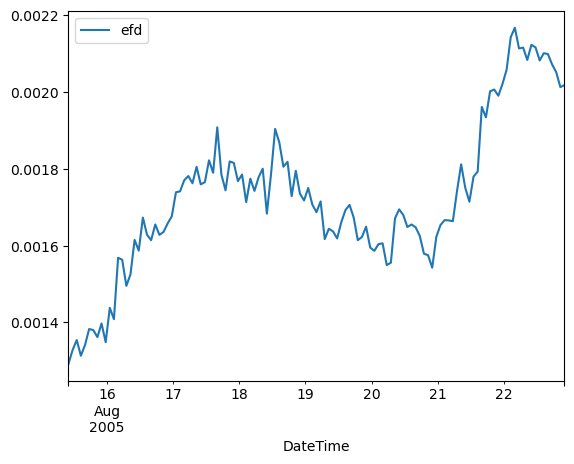

In [ ]:
from scipy.integrate import simpson

step = pd.Timedelta(minutes=90)
s = ch_comb['DateTime'].min()
e = s+step

tol_efd = []
tol_dt = []

while e < ch_comb['DateTime'].max():
    gd_ind = (ch_comb['DateTime'] >= s) & (ch_comb['DateTime'] < e)

    v = ch_comb.loc[gd_ind,'v'].to_numpy()
    d = ch_comb.loc[gd_ind,'rho_x_km'].to_numpy()

    x = ch_comb.loc[gd_ind,'DateTime']
    x = (x-x.min()).dt.total_seconds().to_numpy()
    
    nume = simpson(d*v**3,x)
    deno = simpson(v**3,x)

    tol_efd.append(nume/deno)
    tol_dt.append(s)

    s = s+step
    e = e+step

tol_efd = pd.DataFrame({'efd':tol_efd, 'DateTime':tol_dt})
tol_efd.plot(x='DateTime', y='efd')

<Axes: xlabel='DateTime'>

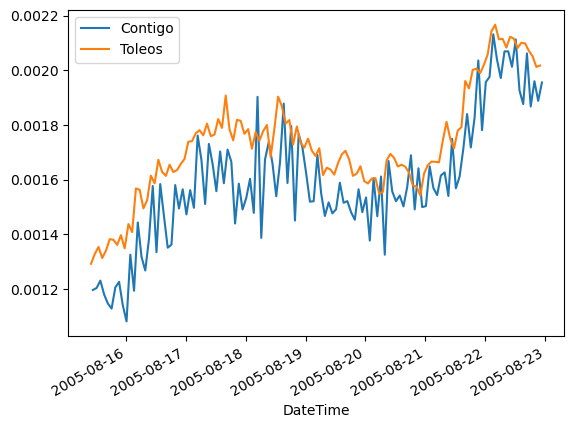

In [ ]:
ax = den_df.plot(x='DateTime',y='efd', label='Contigo')
tol_efd.plot(x='DateTime', y='efd', ax=ax, label='Toleos')


In [ ]:
tol_efd['DateTime'] = tol_efd['DateTime'].astype('datetime64[us]')
tol_efd = pd.merge_asof(tol_efd,den_df,left_on='DateTime',right_on='DateTime',
                        tolerance=pd.Timedelta('5m'))

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import r2_score

print(mean_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(median_absolute_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(mean_absolute_percentage_error(tol_efd['efd_y']*1E3,tol_efd['efd_x']*1E3))
print(r2_score(tol_efd['efd_y'],tol_efd['efd_x']))

ValueError: Input contains NaN.

In [ ]:
import numpy as np

In [ ]:
np.zeros(10)